In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [17]:
base_path = '../output'
# base_path = '../output_400000'
# base_path = '../output_woDrift'
# base_path = '../output_woDiffusion'

grid_r = pd.read_csv(base_path + '/grid_r.dat', sep='\s+', header=None).to_numpy()
grid_z = pd.read_csv(base_path + '/grid_z.dat', sep='\s+', header=None).to_numpy()

n_pos = pd.read_csv(base_path + '/positive_ions.dat', sep='\s+', header=None).to_numpy()
n_neg = pd.read_csv(base_path + '/negative_ions.dat', sep='\s+', header=None).to_numpy()
n_ele = pd.read_csv(base_path + '/electrons.dat', sep='\s+', header=None).to_numpy()

V = pd.read_csv(base_path + '/potential.dat', sep='\s+', header=None).to_numpy()
rho = pd.read_csv(base_path + '/charge_density.dat', sep='\s+', header=None).to_numpy()

E_r = pd.read_csv(base_path + '/electric_field_r.dat', sep='\s+', header=None).to_numpy()
E_z = pd.read_csv(base_path + '/electric_field_z.dat', sep='\s+', header=None).to_numpy()

# T = pd.read_csv('../output/temperature.dat', sep='\s+', header=None).to_numpy()

# it looks like wrong
# J_r = pd.read_csv('../output/current_density_r.dat', sep='\s+', header=None).to_numpy()
# J_z = pd.read_csv('../output/current_density_z.dat', sep='\s+', header=None).to_numpy()

# F_r = pd.read_csv('../output/electric_body_force_r.dat', sep='\s+', header=None).to_numpy()
# F_z = pd.read_csv('../output/electric_body_force_z.dat', sep='\s+', header=None).to_numpy()

q_e = 1.602176634e-19  # elementary charge [C]
K_pos = 2.9e-4 # mobility of positive ions [m2/s V]
K_neg = 2.9e-4 # mobility of negative ions [m2/s V]
K_ele = 0.4  # mobility of electrons [m2/s V]

J_r = q_e*K_pos*np.multiply(n_pos, E_r) - q_e*K_neg*np.multiply(n_neg, E_r) - q_e*K_ele*np.multiply(n_ele, E_r)
J_z = q_e*K_pos*np.multiply(n_pos, E_z) - q_e*K_neg*np.multiply(n_neg, E_z) - q_e*K_ele*np.multiply(n_ele, E_z)

F_r = np.multiply(rho, E_r)
F_z = np.multiply(rho, E_z)

# カラーマップ

Text(0, 0.5, 'z [m]')

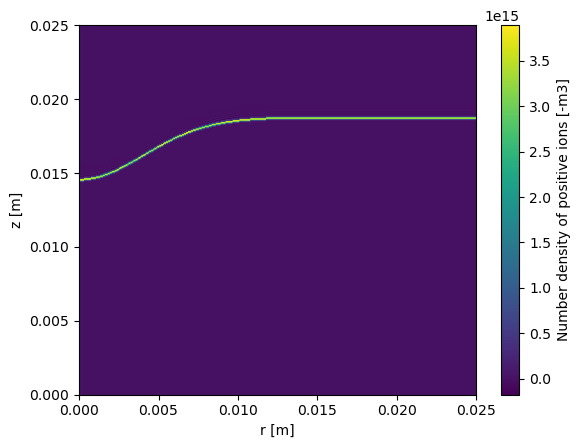

In [18]:
# plt.plot(V)
plt.imshow(np.flip(n_pos, axis=0), extent=[grid_r.min(), grid_r.max(), grid_z.min(), grid_z.max()], origin='lower', aspect='auto')

plt.colorbar(label='Number density of positive ions [-m3]')
plt.xlabel('r [m]')
plt.ylabel('z [m]')
# plt.clim(0, 1e14)
# plt.title('Number density of positive ions [-m3]')

Text(0, 0.5, 'z [m]')

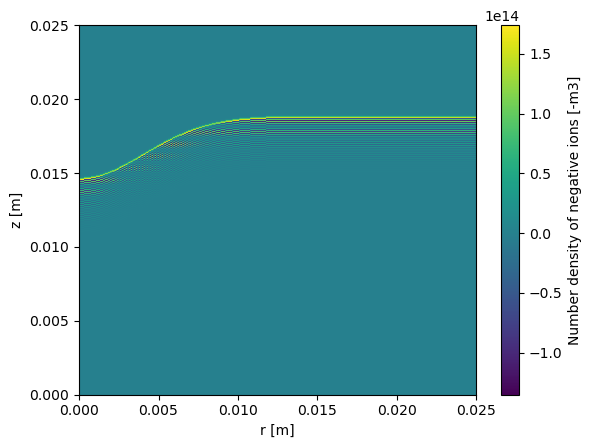

In [19]:

# plt.plot(V)
plt.imshow(np.flip(n_neg, axis=0), extent=[grid_r.min(), grid_r.max(), grid_z.min(), grid_z.max()], origin='lower', aspect='auto')
plt.colorbar(label='Number density of negative ions [-m3]')
plt.xlabel('r [m]')
plt.ylabel('z [m]')
# plt.clim(0.0, np.max(np.abs(n_neg)))
# plt.title('Number density of positive ions [-m3]')

# plt.clim(0, 1e14)
# plt.xlim(0.0, 0.002)
# plt.ylim(0.014, 0.016)

Text(0, 0.5, 'z [m]')

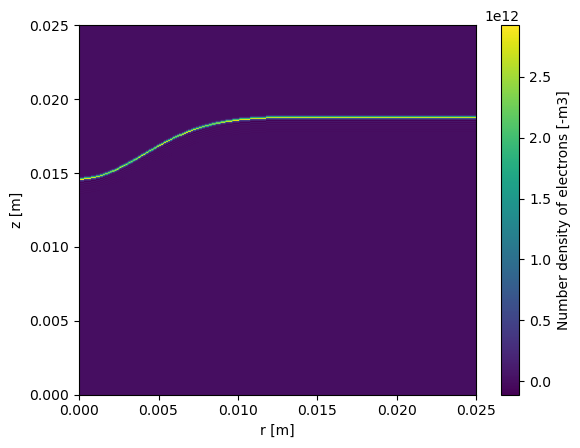

In [20]:
# plt.plot(V)
plt.imshow(np.flip(n_ele, axis=0), extent=[grid_r.min(), grid_r.max(), grid_z.min(), grid_z.max()], origin='lower', aspect='auto')
plt.colorbar(label='Number density of electrons [-m3]')
plt.xlabel('r [m]')
plt.ylabel('z [m]')
# plt.clim(0.0, np.max(np.abs(n_ele)))
# plt.title('Number density of positive ions [-m3]')

Text(0, 0.5, 'z')

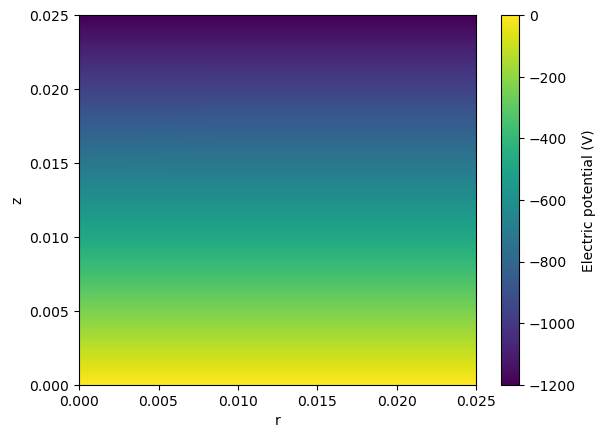

In [21]:
# plt.plot(V)
plt.imshow(np.flip(V, axis=0), extent=[grid_r.min(), grid_r.max(), grid_z.min(), grid_z.max()], origin='lower', aspect='auto')
plt.colorbar(label='Electric potential (V)')
plt.xlabel('r')
plt.ylabel('z')
# plt.title('Potential Distribution')

In [22]:
# # z方向の電界 E_z_calc を電位 V から計算
# # grid_z の z 軸は上から下に値が減少しているため、z方向の差分を取る
# # dz は grid_z の隣接点間隔（既に変数として存在）

# E_z_calc = -np.gradient(V, dz, axis=0)

# plt.imshow(np.flip(E_z_calc, axis=0), extent=[grid_r.min(), grid_r.max(), grid_z.min(), grid_z.max()], origin='lower', aspect='auto', cmap='bwr')
# plt.colorbar(label='Electric field to z direction [C/m3]')
# plt.xlabel('r')
# plt.ylabel('z')


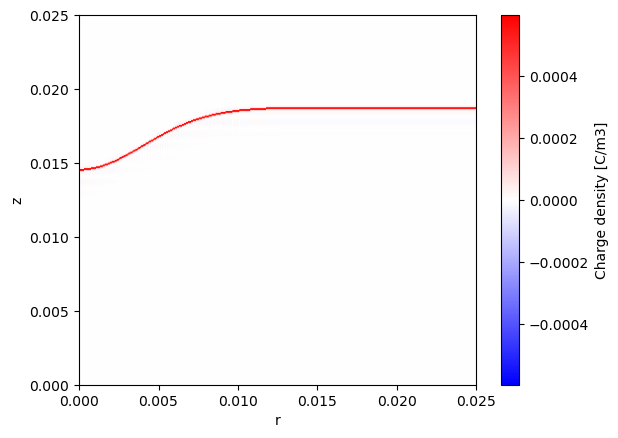

In [23]:
plt.imshow(np.flip(rho, axis=0), extent=[grid_r.min(), grid_r.max(), grid_z.min(), grid_z.max()], origin='lower', aspect='auto', cmap='bwr')
plt.colorbar(label='Charge density [C/m3]')
plt.xlabel('r')
plt.ylabel('z')

max_rho = np.max(np.abs(rho))
plt.clim(- max_rho, max_rho)

# plt.xlim(0.02, 0.025)
# plt.xlim(0.02, 0.025)
# plt.ylim(0.012, 0.017)

# plt.title('Electric charge')

In [24]:
from ipywidgets import interact, FloatSlider
from ipywidgets import FloatRangeSlider
# 可視化範囲（x, y）のスライダーを追加
r_range_slider = FloatRangeSlider(
    value=[grid_r.min(), grid_r.max()],
    min=grid_r.min(),
    max=grid_r.max(),
    step=(grid_r.max() - grid_r.min()) / 100,
    description='r range',
    continuous_update=False
)
z_range_slider = FloatRangeSlider(
    value=[grid_z.min(), grid_z.max()],
    min=grid_z.min(),
    max=grid_z.max(),
    step=(grid_z.max() - grid_z.min()) / 100,
    description='z range',
    continuous_update=False
)

def plot_rho_clim(vmin, vmax, r_range, z_range):
    plt.figure(figsize=(6,5))
    plt.imshow(
        np.flip(rho, axis=0),
        extent=[grid_r.min(), grid_r.max(), grid_z.min(), grid_z.max()],
        origin='lower', aspect='auto', cmap='bwr', vmin=vmin, vmax=vmax
    )
    plt.colorbar(label='Charge density [C/m3]')
    plt.xlabel('r')
    plt.ylabel('z')
    plt.title('Electric charge density')
    plt.xlim(r_range)
    plt.ylim(z_range)
    plt.show()

interact(
    plot_rho_clim,
    vmin=FloatSlider(min=-max_rho, max=0, step=max_rho/100, value=-max_rho, description='vmin'),
    vmax=FloatSlider(min=0, max=max_rho, step=max_rho/100, value=max_rho, description='vmax'),
    r_range=r_range_slider,
    z_range=z_range_slider
)

interactive(children=(FloatSlider(value=-0.000595306742691462, description='vmin', max=0.0, min=-0.00059530674…

<function __main__.plot_rho_clim(vmin, vmax, r_range, z_range)>

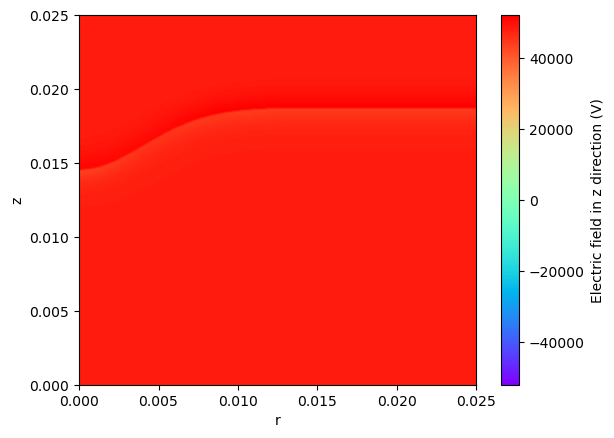

In [25]:
# plt.plot(V)
plt.imshow(np.flip(E_z, axis=0), extent=[grid_r.min(), grid_r.max(), grid_z.min(), grid_z.max()], origin='lower', aspect='auto', cmap='rainbow')
plt.colorbar(label='Electric field in z direction (V)')
plt.xlabel('r')
plt.ylabel('z')


max_E_z = np.max(np.abs(E_z))
plt.clim(- max_E_z, max_E_z)
# plt.title('Potential Distribution')

# ベクタープロット

Text(0.5, 1.0, 'Current density, Max: 6.300e-03 A/m2')

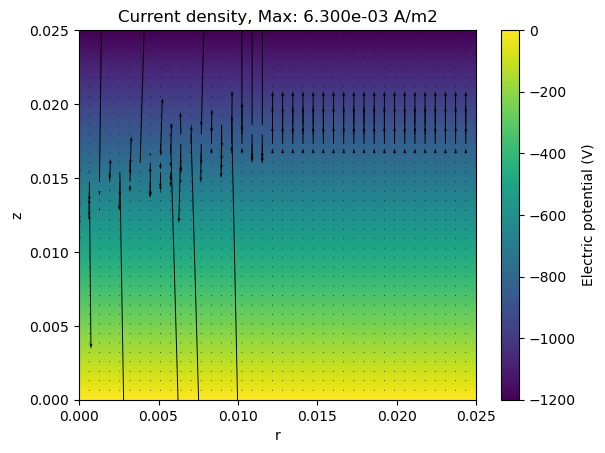

In [26]:
from scipy.ndimage import zoom

def plot_zoomed_data(value_r, value_z, zoom_factor):

    # # 拡大率を計算
    # zoom_factor = 0.2

    global grid_r, grid_z

    # データをリサイズ
    grid_r_new = zoom(grid_r, zoom_factor, order=3)
    grid_z_new = zoom(grid_z, zoom_factor, order=3)
    value_r_new = zoom(value_r, zoom_factor, order=3)
    value_z_new = zoom(value_z, zoom_factor, order=3)

    plt.quiver(grid_r_new, grid_z_new, value_r_new, value_z_new)

    return 

plt.imshow(np.flip(V, axis=0), extent=[grid_r.min(), grid_r.max(), grid_z.min(), grid_z.max()], origin='lower', aspect='auto')
plt.colorbar(label='Electric potential (V)')
plt.xlabel('r')
plt.ylabel('z')

plot_zoomed_data(J_r, J_z, 0.1)

J_max = np.sqrt(J_r*J_r + J_z*J_z).max()
plt.title(f'Current density, Max: {J_max:.3e} A/m2')


Text(0.5, 1.0, 'Electric body force, Max: 2.879e-02 N/m3')

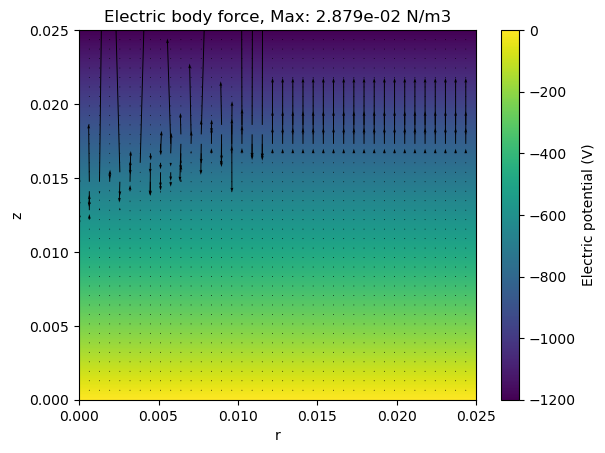

In [27]:
plt.imshow(np.flip(V, axis=0), extent=[grid_r.min(), grid_r.max(), grid_z.min(), grid_z.max()], origin='lower', aspect='auto')
plt.colorbar(label='Electric potential (V)')
plt.xlabel('r')
plt.ylabel('z')

plot_zoomed_data(F_r, F_z, 0.1)

F_max = np.sqrt(F_r*F_r + F_z*F_z).max()
plt.title(f'Electric body force, Max: {F_max*1e-3:.3e} N/m3')

Text(0.5, 1.0, 'Electric field, Max: 52.002 kV/m')

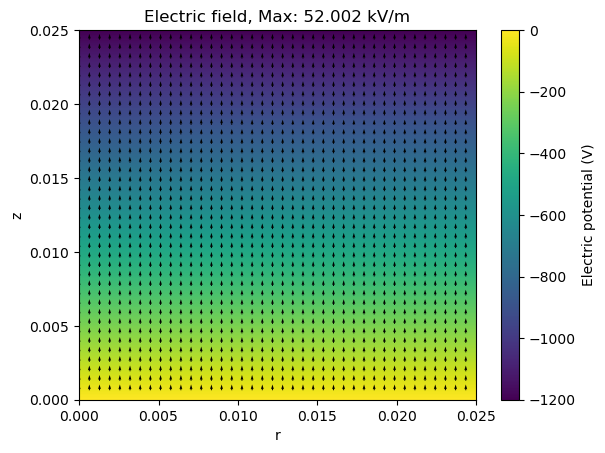

In [28]:
plt.imshow(np.flip(V, axis=0), extent=[grid_r.min(), grid_r.max(), grid_z.min(), grid_z.max()], origin='lower', aspect='auto')
plt.colorbar(label='Electric potential (V)')
plt.xlabel('r')
plt.ylabel('z')

plot_zoomed_data(E_r, E_z, 0.1)

E_max = np.sqrt(E_r*E_r + E_z*E_z).max()
plt.title(f'Electric field, Max: {E_max*1e-3:.3f} kV/m')

# plt.xlim(0.0, 0.002)
# plt.ylim(0.014, 0.016)

# ストリームプロット
plt.streamplotの仕様上grid_zを反転させている

(0.0, 0.01)

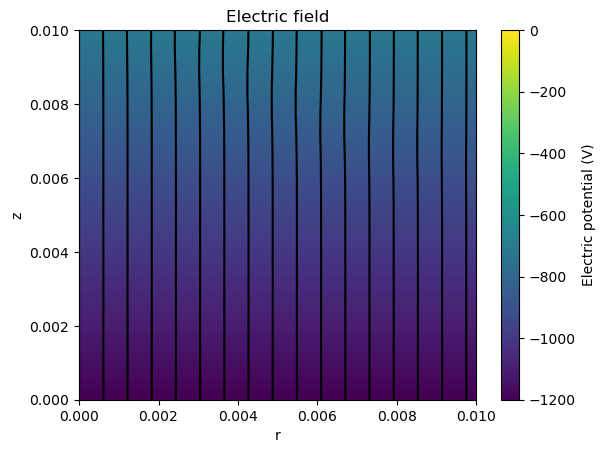

In [29]:
plt.imshow(V, extent=[grid_r.min(), grid_r.max(), grid_z.min(), grid_z.max()], origin='lower', aspect='auto')
plt.colorbar(label='Electric potential (V)')
plt.xlabel('r')
plt.ylabel('z')

plt.streamplot(grid_r, np.flip(grid_z, axis=0), E_r, E_z, density=1.4, linewidth=None, color='black')

plt.title('Electric field')
plt.xlim(0.0, 0.01)
plt.ylim(0.0, 0.01)

In [ ]:
plt.imshow(V, extent=[grid_r.min(), grid_r.max(), grid_z.min(), grid_z.max()], origin='lower', aspect='auto')
plt.colorbar(label='Electric potential (V)')
plt.xlabel('r')
plt.ylabel('z')

plt.streamplot(grid_r, np.flip(grid_z, axis=0), J_r, J_z, density=1.4, linewidth=None, color='black')

plt.title('Current density')
plt.xlim(0.0, 0.01)
plt.ylim(0.0, 0.01)